## Fase 1 - EDA e Visualização dos dados

In [3]:
from sklearn.datasets import fetch_openml


print("Baixando o dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

print("Finalizado")

Baixando o dataset...
Finalizado


In [4]:
#Primeiro pedido:
#SHAPE - imprimir quantidade de linhas e colunas

X = mnist.data #simplificando a vida
y = mnist.target #simplificando a vida

print(f"Qtde. de linhas = ", X.shape[0])
print(f"Qtde. de colunas = ", X.shape[1])
print(f"Qtde. de elementos =", y.shape[0])

Qtde. de linhas =  70000
Qtde. de colunas =  784
Qtde. de elementos = 70000


In [5]:
#Segundo pedido:
#Quantos exemplos existem e mostrar a distribuição

import numpy as np

digitos, quantidades = np.unique(y, return_counts=True)
#print(digitos) #teste

for digito, quantidade in zip(digitos, quantidades):
  print(f"Digito {digito}: {quantidade} exemplos")

#Meu TOC pede para organizar esses dados
#Quero mostrar o percentual dentro do total de exemplos
#Quero mostrar a mediana para vermos a distribuição | vejo uma curva interessante, por isso mediana
#Quero mostrar o delta entre maior e menor

print("----------------------------------------------------")

for digito, quantidade in zip(digitos, quantidades):
  percentual = ((quantidade / np.sum(quantidades))*100)
  print(f"Percentual de participação - Digito {digito}: {percentual:.2f}%")

print("----------------------------------------------------")
print("Mediana:", np.median(quantidades))
print("Delta:", np.max(quantidades) - np.min(quantidades))

Digito 0: 6903 exemplos
Digito 1: 7877 exemplos
Digito 2: 6990 exemplos
Digito 3: 7141 exemplos
Digito 4: 6824 exemplos
Digito 5: 6313 exemplos
Digito 6: 6876 exemplos
Digito 7: 7293 exemplos
Digito 8: 6825 exemplos
Digito 9: 6958 exemplos
----------------------------------------------------
Percentual de participação - Digito 0: 9.86%
Percentual de participação - Digito 1: 11.25%
Percentual de participação - Digito 2: 9.99%
Percentual de participação - Digito 3: 10.20%
Percentual de participação - Digito 4: 9.75%
Percentual de participação - Digito 5: 9.02%
Percentual de participação - Digito 6: 9.82%
Percentual de participação - Digito 7: 10.42%
Percentual de participação - Digito 8: 9.75%
Percentual de participação - Digito 9: 9.94%
----------------------------------------------------
Mediana: 6930.5
Delta: 1564


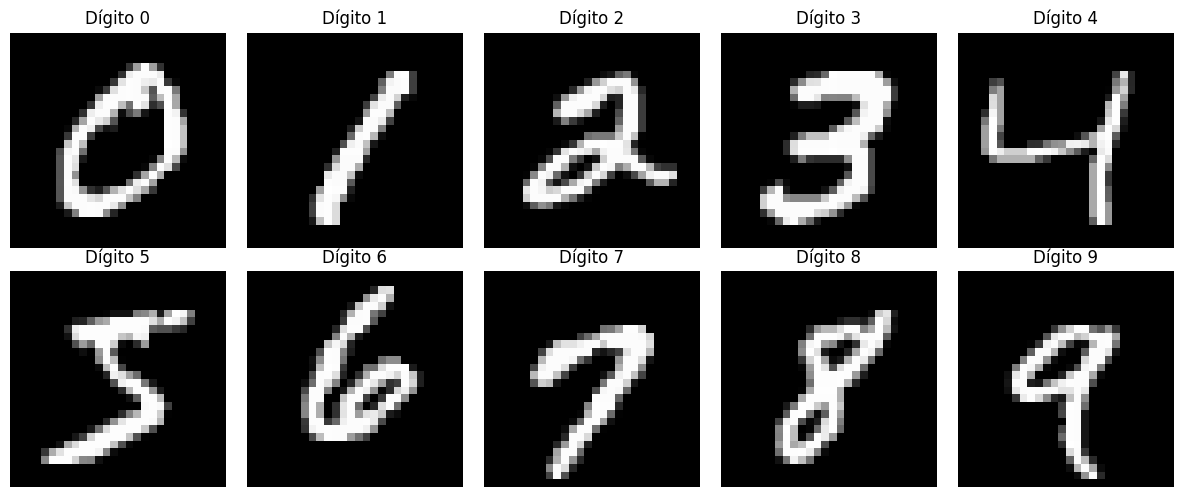

In [6]:
#Vamos criar uma grade de imagens com matplotlib
#reshape?

import matplotlib.pyplot as plt

fig, eixos = plt.subplots(nrows=2, ncols=5, figsize=(12,5))
eixos = eixos.flatten()

#achando o indice: np.where(y == 'digito')[0][0]
for digito, eixo in zip(digitos,eixos):
  indice = np.where(y == str(digito))[0][0]
  #print(indice) #teste
  X_reshaped = X[indice].reshape(28,28)
  eixo.imshow(X_reshaped, cmap='gray')
  eixo.set_title(f"Dígito {digito}")
  eixo.axis('off') #resolvi tirar as anotações do eixo, mais limpo

plt.tight_layout()
plt.show()


# **O que significa cada pixel valer de 0 a 255?**

Cada pixel usa 1 byte (8 bits) de memória, permitindo representar 256 (2^8) valores de intensidade de luz. Em outras palavras, no MNIST nós temos diferentes tons de cinza.

E em imagens em escala de cinza:
O valor 0 representa a ausência total de brilho (preto)
O valor 255 representa a intensidade máxima (branco)

Os números intermediários (1 a 254) representam os diferentes tons de cinza (usados para suavizar as bordas do traço).

# **Por que uma imagem 28x28 vira um vetor de 784 números?**

A imagem original é organizada como uma grade bidimensional (matriz tipo [n][k], onde n e k são numeros reais positivos) de 28 linhas e 28 colunas, totalizando 784 pixels.

Para alimentar modelos de aprendizado de máquina tradicionais e camadas densas de redes neurais, realizamos um processo chamado flattening (achatamento), empilhando todas as linhas em uma única fila unidimensional de 784 posições.

## Fase 2: Pipeline de pré-processamento e divisão dos dados

In [8]:
#Dividindo em treino, validação, testes (80/20). Escolhido 80/20 por uma questão de otimização de tempo pessoal até a entrega.
#Stratify=y para manter a proporção? test_size = 0.2

from sklearn.model_selection import train_test_split

dados_exemplo = X
rotulos_exemplo = y

X_treino, X_teste, y_treino, y_teste = train_test_split(
    dados_exemplo,
    rotulos_exemplo,
    test_size=0.2,
    stratify=rotulos_exemplo,
    random_state=42
)

#checagem de rotina
#print(f"X (x,y) = ", X_treino.shape)
#print(f"Y (elementos) =", y_treino.shape[0])
#estamos pegando 80% para treino, 20% para testes: legal okok


In [9]:
#Vamos normalizar os dados separados (avoid data leakage)
#Por que? Lembra do primeiro projeto?
#Algoritmos como KNN medem o quão longe uma coisa está da outra, com números inflados, corremos o risco de instabilidades e falta de sensibilidade às diferenças reais.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_treino_normalizado = scaler.fit_transform(X_treino)
X_teste_normalizado = scaler.transform(X_teste)

#Testes
#print(X_treino.min())
#print(X_treino.max())
#print(X_treino_normalizado.min())
#print(X_treino_normalizado.max())
#print(X_treino.shape)
#print(X_treino_normalizado.shape)
#Achando indice do treino normalizado com o y_treino, retorna imagens corretas, mesmos codigos acima
#good to go

# **Por que a normalização ajuda?**

Similarmente ao primeiro projeto, modelos que usam distância, quanto menor a distância entre os pontos (nesse caso, os pontos que formam a imgem) maior a precisão e sensibilidade do modelo. Por isso reduzimos de 0 a 255 para 0.0 a 1.0. A exemplo do professor: qual a precisão de um passo de 200 unidades de distância contra um de 1 unidade de distância?

Por isso normalizados, reduzindo a distância dos passos.

# **E para rede neural?**

Pesquisando encontrei que o motivo é similar. As entradas grandes tornam o treino instável e demorado. Com entradas menores tende a ser mais rápido e estável.

##Fase 3 - Implementação e treinamento dos 3 Modelos

In [11]:
#Combinação segura de modelos: KNN, Random Forest e MLP simples
#Para KNN, hipeparametro: n_neighbors, ou seja não deixar o KNeighhborsClassifier() em default
#Decidir nos números e justificar pro exercício
#Para Random Forest: n_estimators e max_depth, quantas arvores e qual a profundidade delas
#Para MLP simples, número de neuronios e taxa de aprendizado.

from sklearn.neighbors import KNeighborsClassifier
import time

#Parametros, em lista para fazer os testes com diferentes vizinhos para KNN
lista = [3,5,7]
for i in lista:
  N = i

  knn = KNeighborsClassifier(n_neighbors=N, weights='distance')

  #random_state serve para reproduzir a aleatoriedade de forma equivalente no futuro
  #A fase 4 pede comparativo, então vou marcar o delta tempo dos 3 modelos.


  #--------------KNN--------------
  print("-"*15, f"KNN = {N}", "-"*15)

  #FIT
  inicio = time.time()
  knn.fit(X_treino_normalizado, y_treino)
  tempo_treino_knn = time.time() - inicio
  print(f"Tempo de treino KNN: {tempo_treino_knn:.2f} segundos")

  #PREDICT
  inicio_predicao = time.time()
  knn_predicoes = knn.predict(X_teste_normalizado)
  tempo_predicao_knn = time.time() - inicio_predicao
  print(f"Tempo de predição KNN: {tempo_predicao_knn:.2f} segundos")

  #TOTAL
  tempo_total_knn = tempo_treino_knn + tempo_predicao_knn
  print(f"Tempo total KNN: {tempo_total_knn:.2f} segundos")

K = 3
--------------- KNN = 3 ---------------
Tempo de treino KNN: 0.17 segundos
Tempo de predição KNN: 52.90 segundos
Tempo total KNN: 53.07 segundos
K = 5
--------------- KNN = 5 ---------------
Tempo de treino KNN: 0.09 segundos
Tempo de predição KNN: 52.20 segundos
Tempo total KNN: 52.29 segundos
K = 7
--------------- KNN = 7 ---------------
Tempo de treino KNN: 0.09 segundos
Tempo de predição KNN: 55.38 segundos
Tempo total KNN: 55.47 segundos


# Os três estavam em uma mesma célula, resolvi separar por performance do projeto.

In [17]:
from sklearn.ensemble import RandomForestClassifier
import time

#Parametros, em lista para fazer dois testes de estimativa
lista_rf = [50,100,200]

for k in lista_rf:
  N = k

  rf = RandomForestClassifier(n_estimators=N, max_depth=20, random_state=42)

  #--------------Random Forest--------------
  print("-"*15, f"Random Forest: n_estimators = {N}", "-"*15)
  #FIT
  inicio = time.time() #restart
  rf.fit(X_treino_normalizado, y_treino)
  tempo_treino_rf = time.time() - inicio
  print(f"Tempo de treino Random Forest: {tempo_treino_rf:.2f} segundos")

  #PREDICT
  inicio = time.time()
  rf_predicoes = rf.predict(X_teste_normalizado)
  tempo_predicao_rf = time.time() - inicio
  print(f"Tempo de predição Random Forest: {tempo_predicao_rf:.2f} segundos")

  #TOTAL
  tempo_total_rf = tempo_treino_rf + tempo_predicao_rf
  print(f"Tempo total Random Forest: {tempo_total_rf:.2f} segundos")

--------------- Random Forest = 50 ---------------
Tempo de treino Random Forest: 28.28 segundos
Tempo de predição Random Forest: 0.32 segundos
Tempo total Random Forest: 28.60 segundos
--------------- Random Forest = 100 ---------------
Tempo de treino Random Forest: 51.77 segundos
Tempo de predição Random Forest: 0.63 segundos
Tempo total Random Forest: 52.41 segundos
--------------- Random Forest = 200 ---------------
Tempo de treino Random Forest: 104.20 segundos
Tempo de predição Random Forest: 1.21 segundos
Tempo total Random Forest: 105.41 segundos


In [ ]:
from sklearn.neural_network import MLPClassifier #utilizado por ser similar aos dois acima, economia de tempo para a entrega em 2 dias
import time

#Parametros
mlp = MLPClassifier(hidden_layer_sizes=(128,), learning_rate_init=0.001, max_iter=50, random_state=42)

#--------------MLP--------------
print("-"*15, "MLP", "-"*15)
#FIT
inicio = time.time() #restart
mlp.fit(X_treino_normalizado, y_treino)
tempo_treino_mlp = time.time() - inicio
print(f"Tempo de treino MLP: {tempo_treino_mlp:.2f} segundos")

#PREDICT
inicio = time.time()
mlp_predicoes = mlp.predict(X_teste_normalizado)
tempo_predicao_mlp = time.time() - inicio
print(f"Tempo de predição MLP: {tempo_predicao_mlp:.2f} segundos")

#TOTAL
tempo_total_mlp = tempo_treino_mlp + tempo_predicao_mlp
print(f"Tempo total MLP: {tempo_total_mlp:.2f} segundos")

Para o KNN, testamos n_neighbors em {3, 5, 7}, com tempo de execução praticamente insensível ao valor escolhido.

Para o Random Forest, testamos n_estimators em {50, 100, 200}, com tempo escalando quase linearmente com o número de árvores com o mesmo max_depth.

Para o MLP, os hiperparâmetros (128 neurônios, taxa de aprendizado 0.001) foram definidos por raciocínio técnico, dado o custo computacional mais alto de testar variações empiricamente dentro do prazo disponível. E devido ao longo tempo de processamento, não foi testado de outro modo.